#**Problem Statement:**
 Many small online retailers and new entrants to the online retail sector are keen to practice data mining and consumer-centric marketing in their businesses.
 The main purpose of this analysis is to help the business better understand its customers and therefore conduct customer-centric marketing more effectively.

## **Dataset Info:**
Online Retail II data set contains all the transactions occurring for a UK-based and registered, non-store online retail between 01/12/2009 and 09/12/2011.The company mainly sells unique all-occasion gift-ware. Many customers of the company are wholesalers.

**Variable Info:**
- InvoiceNo: Invoice number. Nominal. A 6-digit integral number uniquely assigned to each transaction. If this code starts with the letter 'c', it indicates a cancellation.
- StockCode: Product (item) code. Nominal. A 5-digit integral number uniquely assigned to each distinct product.
- Description: Product (item) name. Nominal.
- Quantity: The quantities of each product (item) per transaction. Numeric.
InvoiceDate: Invice date and time. Numeric. The day and time when a transaction was generated.
- UnitPrice: Unit price. Numeric. Product price per unit in sterling (Â£).
- CustomerID: Customer number. Nominal. A 5-digit integral number uniquely assigned to each customer.
- Country: Country name. Nominal. The name of the country where a customer resides.



**Importing required Libraries:**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

In [2]:
df = pd.read_excel('data/online_retail_II.xlsx', sheet_name = 0)
df.head(10)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
5,489434,22064,PINK DOUGHNUT TRINKET POT,24,2009-12-01 07:45:00,1.65,13085.0,United Kingdom
6,489434,21871,SAVE THE PLANET MUG,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
7,489434,21523,FANCY FONT HOME SWEET HOME DOORMAT,10,2009-12-01 07:45:00,5.95,13085.0,United Kingdom
8,489435,22350,CAT BOWL,12,2009-12-01 07:46:00,2.55,13085.0,United Kingdom
9,489435,22349,"DOG BOWL , CHASING BALL DESIGN",12,2009-12-01 07:46:00,3.75,13085.0,United Kingdom


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 525461 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      525461 non-null  object        
 1   StockCode    525461 non-null  object        
 2   Description  522533 non-null  object        
 3   Quantity     525461 non-null  int64         
 4   InvoiceDate  525461 non-null  datetime64[ns]
 5   Price        525461 non-null  float64       
 6   Customer ID  417534 non-null  float64       
 7   Country      525461 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 32.1+ MB


In [4]:
df.isna().sum()

Invoice             0
StockCode           0
Description      2928
Quantity            0
InvoiceDate         0
Price               0
Customer ID    107927
Country             0
dtype: int64

In [5]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
Quantity,525461.0,10.337667,-9600.0,1.0,3.0,10.0,19152.0,107.42411
InvoiceDate,525461,2010-06-28 11:37:36.845017856,2009-12-01 07:45:00,2010-03-21 12:20:00,2010-07-06 09:51:00,2010-10-15 12:45:00,2010-12-09 20:01:00,NaN
Price,525461.0,4.688834,-53594.36,1.25,2.1,4.21,25111.09,146.126914
Customer ID,417534.0,15360.645478,12346.0,13983.0,15311.0,16799.0,18287.0,1680.811316


Quantity min is negative and price is negative as well.

Looking at object datatype variable description.

In [6]:
df.describe(include = 'O')

,Invoice,StockCode,Description,Country
count,525461,525461,522533,525461
unique,28816,4632,4681,40
top,537434,85123A,WHITE HANGING HEART T-LIGHT HOLDER,United Kingdom
freq,675,3516,3549,485852


- Invoice have 28816 unique values, with mode value 537434 having frequency = 675.
- StockCode have 4632 uniques values with mode value 85123A
- Maximum number of product that has been purchased online or say that was in demand in online market in the year 2009 was **WHITE HANGING HEART T-LIGHT HOLDER	United**.
- The country from where maximum online buyers come from is **United Kingdom**.
About **485852** buyers from UK, a significant portion of population, data is not a good representative of online buyers around the globe.

In [7]:
df[df['Customer ID'].isna()]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
263,489464,21733,85123a mixed,-96,2009-12-01 10:52:00,0.00,NaN,United Kingdom
283,489463,71477,short,-240,2009-12-01 10:52:00,0.00,NaN,United Kingdom
284,489467,85123A,21733 mixed,-192,2009-12-01 10:53:00,0.00,NaN,United Kingdom
470,489521,21646,NaN,-50,2009-12-01 11:44:00,0.00,NaN,United Kingdom
577,489525,85226C,BLUE PULL BACK RACING CAR,1,2009-12-01 11:49:00,0.55,NaN,United Kingdom
...,...,...,...,...,...,...,...,...
525231,538159,21324,NaN,-18,2010-12-09 17:17:00,0.00,NaN,United Kingdom
525232,538158,20892,NaN,-32,2010-12-09 17:17:00,0.00,NaN,United Kingdom
525233,538160,20956,NaN,288,2010-12-09 17:18:00,0.00,NaN,United Kingdom
525234,538161,46000S,Dotcom sales,-100,2010-12-09 17:25:00,0.00,NaN,United Kingdom


Would be dropping these rows since these customers cannot be tracked.
Question.. do we need customer Id for our analysis, segmentation purpose, does it plays any role.
Yes there are 4384 unique customer IDs that is potential online buyers.

In [8]:
df['Customer ID'].unique().shape

(4384,)

In [9]:
df[df.Quantity < 0].sample(10)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
319843,C520556,22325,MOBILE VINTAGE HEARTS,-3,2010-08-26 16:38:00,4.95,14342.0,United Kingdom
179457,C506409,BANK CHARGES,Bank Charges,-1,2010-04-29 13:50:00,354.43,NaN,United Kingdom
191658,C507598,84687,BEACH HUT SHELF W 3 DRAWERS,-2,2010-05-10 13:22:00,5.95,15555.0,United Kingdom
255848,C514095,20682,RED SPOTTY CHILDS UMBRELLA,-12,2010-06-30 12:17:00,2.75,12770.0,Japan
194013,507878,79140,NaN,-25,2010-05-11 15:01:00,0.00,NaN,United Kingdom
23265,C491190,21535,RETRO SPOT SMALL MILK JUG,-6,2009-12-10 12:38:00,2.55,16057.0,United Kingdom
280512,516724,84356,damaged,-14,2010-07-22 12:40:00,0.00,NaN,United Kingdom
285,C489476,22149,FELTCRAFT 6 FLOWER FRIENDS,-6,2009-12-01 10:55:00,2.10,13293.0,United Kingdom
465844,C533347,21258,VICTORIAN SEWING BOX LARGE,-6,2010-11-17 09:15:00,10.95,15100.0,United Kingdom
420568,C529606,22730,ALARM CLOCK BAKELIKE IVORY,-8,2010-10-29 10:28:00,3.75,17396.0,United Kingdom


Invoice starting with C indicates cancellation.

In [10]:
df.Invoice = df.Invoice.astype('str')
invoice_first_letter = df.Invoice.str.get(0)
invoice_first_letter.unique()

array(['4', 'C', '5', 'A'], dtype=object)

There are some orders starting with 'A' as well.

In [11]:
df[df.Invoice.str.startswith('A')] # can be removed.

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
179403,A506401,B,Adjust bad debt,1,2010-04-29 13:36:00,-53594.36,NaN,United Kingdom
276274,A516228,B,Adjust bad debt,1,2010-07-19 11:24:00,-44031.79,NaN,United Kingdom
403472,A528059,B,Adjust bad debt,1,2010-10-20 12:04:00,-38925.87,NaN,United Kingdom


In [12]:
df.StockCode.unique().shape

(4632,)

In [13]:
df[df.StockCode.astype('str').str.endswith('B')]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
23,489436,35004B,SET OF 3 BLACK FLYING DUCKS,12,2009-12-01 09:06:00,4.65,13078.0,United Kingdom
42,489437,84507B,STRIPES DESIGN MONKEY DOLL,6,2009-12-01 09:08:00,2.55,15362.0,United Kingdom
62,489438,84031B,CHARLIE LOLA BLUE HOT WATER BOTTLE,56,2009-12-01 09:24:00,3.00,18102.0,United Kingdom
64,489438,84032B,CHARLIE + LOLA RED HOT WATER BOTTLE,56,2009-12-01 09:24:00,1.90,18102.0,United Kingdom
66,489438,84519B,CARROT CHARLIE+LOLA COASTER SET,60,2009-12-01 09:24:00,2.40,18102.0,United Kingdom
...,...,...,...,...,...,...,...,...
525187,538156,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-09 16:53:00,3.25,15555.0,United Kingdom
525269,538163,15060B,FAIRY CAKE DESIGN UMBRELLA,1,2010-12-09 17:27:00,3.75,17841.0,United Kingdom
525282,C538164,35004B,SET OF 3 BLACK FLYING DUCKS,-1,2010-12-09 17:32:00,1.95,14031.0,United Kingdom
525389,538170,85232B,SET OF 3 BABUSHKA STACKING TINS,2,2010-12-09 19:32:00,4.95,13969.0,United Kingdom


In [14]:
df.Country.unique()

array(['United Kingdom', 'France', 'USA', 'Belgium', 'Australia', 'EIRE',
       'Germany', 'Portugal', 'Japan', 'Denmark', 'Nigeria',
       'Netherlands', 'Poland', 'Spain', 'Channel Islands', 'Italy',
       'Cyprus', 'Greece', 'Norway', 'Austria', 'Sweden',
       'United Arab Emirates', 'Finland', 'Switzerland', 'Unspecified',
       'Malta', 'Bahrain', 'RSA', 'Bermuda', 'Hong Kong', 'Singapore',
       'Thailand', 'Israel', 'Lithuania', 'West Indies', 'Lebanon',
       'Korea', 'Brazil', 'Canada', 'Iceland'], dtype=object)

In [15]:
df.Country.value_counts()

Country
United Kingdom          485852
EIRE                      9670
Germany                   8129
France                    5772
Netherlands               2769
Spain                     1278
Switzerland               1187
Portugal                  1101
Belgium                   1054
Channel Islands            906
Sweden                     902
Italy                      731
Australia                  654
Cyprus                     554
Austria                    537
Greece                     517
United Arab Emirates       432
Denmark                    428
Norway                     369
Finland                    354
Unspecified                310
USA                        244
Japan                      224
Poland                     194
Malta                      172
Lithuania                  154
Singapore                  117
RSA                        111
Bahrain                    107
Canada                      77
Hong Kong                   76
Thailand                    76


In [16]:
df.Country.isna().sum() # no missing values in country column

np.int64(0)

## **Data Cleaning**

### **Checking for duplicate rows**

In [17]:
cleaned_df = df.copy()

In [18]:
cleaned_df.duplicated().sum() # 6865 duplicate rows to remove

np.int64(6865)

In [19]:
cleaned_df = cleaned_df.drop_duplicates()

In [20]:
cleaned_df = cleaned_df[cleaned_df['Customer ID'].isna() == False] # dropping missing customer id's

In [21]:
# keeping invoice rows with only numerals and no cancellation and A whatever it was
indices = cleaned_df[cleaned_df.Invoice.str.startswith('C') == True].index

In [22]:
A_indices = cleaned_df[cleaned_df.Invoice.str.startswith('A') == True].index

In [23]:
indices.append(A_indices)

Index([   178,    179,    180,    181,    182,    183,    184,    185,    186,
          196,
       ...
       524688, 524691, 524692, 524693, 524694, 524695, 524696, 524697, 524698,
       525282],
      dtype='int64', length=9816)

In [24]:
cleaned_df = cleaned_df.drop(index = indices.append(A_indices)) # now we have invoice with only valid numerals.

In [25]:
cleaned_df[cleaned_df.Invoice.astype('str').str.match('^\\d{6}$') == False] # checking if there is another pattern left

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country


In [26]:
unique_stockcodes = df.StockCode.unique()
count = 0
for i in unique_stockcodes:
  if len(str(i)) != 5:
    count += 1
print(count) # 1675 stockcodes have other than 5 digits

1675


In [27]:
def unique_stockcodes(n):
  count = 0
  unique = cleaned_df.StockCode.unique()
  for i in unique:
    if len(str(i)) == n:
      print(i)
      count +=1

In [28]:
print(unique_stockcodes(1))

M
D
None


In [29]:
unique_stockcodes(2) # stockcodes with only one literal

C2


In [30]:
unique_stockcodes(3)

In [31]:
unique_stockcodes(4)

POST
PADS


In [32]:
unique_stockcodes(7)

79323LP
15056BL
79323GR
TEST001
TEST002
ADJUST2


In [33]:
unique_stockcodes(8)

In [34]:
unique_stockcodes(9)

In [35]:
unique_stockcodes(10)

In [36]:
unique_stockcodes(11)

In [37]:
unique_stockcodes(12)

BANK CHARGES


In [38]:
cleaned_df[cleaned_df.StockCode == 'BANK CHARGES'] # can be dropped

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
18466,490948,BANK CHARGES,Bank Charges,1,2009-12-08 14:29:00,15.0,16805.0,United Kingdom
94431,498269,BANK CHARGES,Bank Charges,1,2010-02-17 15:03:00,15.0,16928.0,United Kingdom
148098,503497,BANK CHARGES,Bank Charges,1,2010-04-01 12:07:00,15.0,17539.0,United Kingdom
153573,503960,BANK CHARGES,Bank Charges,1,2010-04-08 16:50:00,15.0,12843.0,United Kingdom
167424,505204,BANK CHARGES,Bank Charges,1,2010-04-20 16:24:00,15.0,17448.0,United Kingdom
206572,509375,BANK CHARGES,Bank Charges,1,2010-05-21 14:40:00,15.0,17448.0,United Kingdom
210149,509669,BANK CHARGES,Bank Charges,1,2010-05-25 12:03:00,15.0,17448.0,United Kingdom
231102,511774,BANK CHARGES,Bank Charges,1,2010-06-10 12:16:00,15.0,17032.0,United Kingdom
240612,512658,BANK CHARGES,Bank Charges,1,2010-06-17 11:24:00,15.0,14085.0,United Kingdom
272460,515845,BANK CHARGES,Bank Charges,1,2010-07-15 11:21:00,15.0,14606.0,United Kingdom


In [39]:
cleaned_df[cleaned_df.StockCode == 'TEST001'] # test product, it can be dropped
cleaned_df = cleaned_df[cleaned_df.StockCode != 'TEST001']

In [40]:
cleaned_df = cleaned_df[cleaned_df.StockCode != 'TEST002']

In [41]:
cleaned_df = cleaned_df[cleaned_df.StockCode != 'ADJUST2']

In [42]:
cleaned_df[cleaned_df.StockCode == 'C2'] # probably is delivery related thing and not a product will remove
cleaned_df = cleaned_df[cleaned_df.StockCode != 'C2']

In [43]:
cleaned_df[cleaned_df.StockCode == 'M'] # will keep it

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
11310,490300,M,Manual,1,2009-12-04 14:19:00,0.85,12970.0,United Kingdom
11311,490300,M,Manual,1,2009-12-04 14:19:00,0.21,12970.0,United Kingdom
16107,490727,M,Manual,1,2009-12-07 16:38:00,0.00,17231.0,United Kingdom
17386,490760,M,Manual,1,2009-12-08 09:49:00,10.00,14295.0,United Kingdom
17887,490881,M,Manual,1,2009-12-08 12:58:00,10.00,16210.0,United Kingdom
...,...,...,...,...,...,...,...,...
516892,537435,M,Manual,2,2010-12-06 16:58:00,5.95,17920.0,United Kingdom
521074,537800,M,Manual,12,2010-12-08 13:08:00,0.19,12748.0,United Kingdom
521122,537804,M,Manual,12,2010-12-08 13:17:00,2.95,12748.0,United Kingdom
521124,537804,M,Manual,12,2010-12-08 13:17:00,0.19,12748.0,United Kingdom


In [44]:
cleaned_df[cleaned_df.StockCode == 'D'] # related discounted items, will drop since less in number
cleaned_df = cleaned_df[cleaned_df.StockCode != 'D']

In [45]:
cleaned_df.info() # no non null fields left.

<class 'pandas.core.frame.DataFrame'>
Index: 400807 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      400807 non-null  object        
 1   StockCode    400807 non-null  object        
 2   Description  400807 non-null  object        
 3   Quantity     400807 non-null  int64         
 4   InvoiceDate  400807 non-null  datetime64[ns]
 5   Price        400807 non-null  float64       
 6   Customer ID  400807 non-null  float64       
 7   Country      400807 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 27.5+ MB


In [46]:
cleaned_df.isna().sum()

Invoice        0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
Price          0
Customer ID    0
Country        0
dtype: int64

In [47]:
cleaned_df.describe()

,Quantity,InvoiceDate,Price,Customer ID
count,400807.000000,400807,400807.000000,400807.000000
mean,13.772384,2010-07-01 04:50:16.028312832,3.289037,15361.690754
min,1.000000,2009-12-01 07:45:00,0.000000,12346.000000
25%,2.000000,2010-03-26 13:13:00,1.250000,13985.000000
50%,5.000000,2010-07-09 10:26:00,1.950000,15311.000000
75%,12.000000,2010-10-14 13:57:00,3.750000,16805.000000
max,19152.000000,2010-12-09 20:01:00,10953.500000,18287.000000
std,97.656185,NaN,35.034311,1680.781996


- negative quantity removed, negative prices removed.
- minimum price is 0, maybe counts for free gifts and not purchashing, will remove it


In [48]:
cleaned_df = cleaned_df[cleaned_df.Price > 0]

In [49]:
cleaned_df.describe()

,Quantity,InvoiceDate,Price,Customer ID
count,400778.000000,400778,400778.000000,400778.000000
mean,13.771235,2010-07-01 04:54:21.064179968,3.289275,15361.775764
min,1.000000,2009-12-01 07:45:00,0.001000,12346.000000
25%,2.000000,2010-03-26 13:28:00,1.250000,13985.000000
50%,5.000000,2010-07-09 10:26:00,1.950000,15311.000000
75%,12.000000,2010-10-14 13:57:00,3.750000,16805.000000
max,19152.000000,2010-12-09 20:01:00,10953.500000,18287.000000
std,97.654513,NaN,35.035568,1680.745512


In [50]:
len(cleaned_df) / len(df) * 100

76.27169285636802

76.27 % data retained after cleaning.

<Axes: xlabel='Quantity', ylabel='Count'>

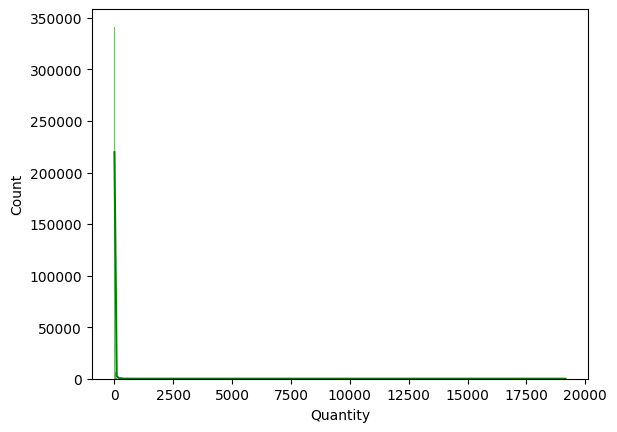

In [51]:
sns.histplot(kde = True, data = cleaned_df.Quantity, color = 'green' )

### **Feature Engineering:**
Features we are interested in:
- **Recency** - latest purchase
- **Frequncy** - number of times they made a purchase
- **Monetary Value** - Sum total of monetary amount that customer has purchased


In [52]:
cleaned_df['SalesLineTotal'] = cleaned_df['Quantity'] * cleaned_df['Price']
cleaned_df

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,SalesLineTotal
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.40
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.00
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.00
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.80
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.00
...,...,...,...,...,...,...,...,...,...
525456,538171,22271,FELTCRAFT DOLL ROSIE,2,2010-12-09 20:01:00,2.95,17530.0,United Kingdom,5.90
525457,538171,22750,FELTCRAFT PRINCESS LOLA DOLL,1,2010-12-09 20:01:00,3.75,17530.0,United Kingdom,3.75
525458,538171,22751,FELTCRAFT PRINCESS OLIVIA DOLL,1,2010-12-09 20:01:00,3.75,17530.0,United Kingdom,3.75
525459,538171,20970,PINK FLORAL FELTCRAFT SHOULDER BAG,2,2010-12-09 20:01:00,3.75,17530.0,United Kingdom,7.50


In [53]:
# now we aggregate sales by grouping by customer ID and then c frequencomputing aggregate for recency value,y value and monetary value
aggregated_df = cleaned_df.groupby(by = 'Customer ID', as_index = False).agg(
    MonetaryValue = ('SalesLineTotal', 'sum'),
    Frequency = ('Invoice', 'nunique'),
    LastInvoiceDate = ('InvoiceDate', 'max')
 )
  # becoz we don't want customer id to be used as index
  # Monetary value of each customer by summing total amount spent
  # Frequency by checking how many invoices are there for each customer
  # recency by getting most recent date of each customer id
aggregated_df.head()


,Customer ID,MonetaryValue,Frequency,LastInvoiceDate
0,12346.0,169.36,2,2010-06-28 13:53:00
1,12347.0,1323.32,2,2010-12-07 14:57:00
2,12348.0,222.16,1,2010-09-27 14:59:00
3,12349.0,2671.14,3,2010-10-28 08:23:00
4,12351.0,300.93,1,2010-11-29 15:23:00


Customer **12346** have spent total **169.36** pounds over **2** purchases and most recent was made on **2010-06-28**

In [54]:
# now to get recency feature
max_invoice_date = aggregated_df.LastInvoiceDate.max()

max_invoice_date

Timestamp('2010-12-09 20:01:00')

this will be our recent stamp date using which we will compare other recent purchases, obviously cannot take todays date for reference since the dataset is of 2009 and until 2025 many purchases have been made so we can use this as a reference.

In [55]:
aggregated_df['Recency'] = (max_invoice_date - aggregated_df.LastInvoiceDate).dt.days

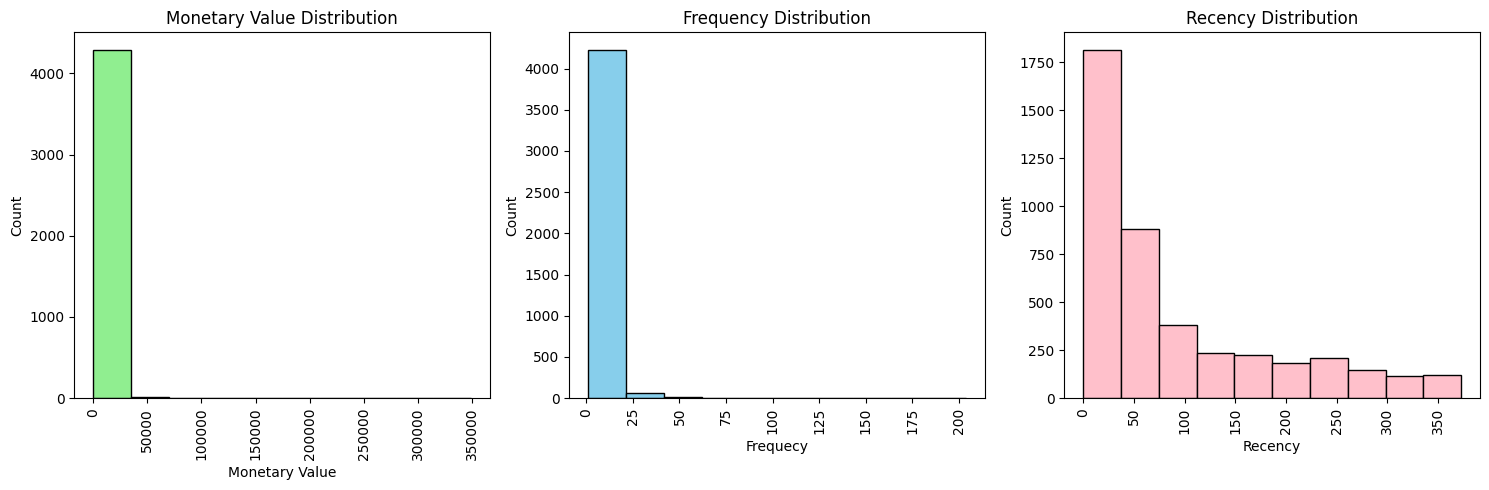

In [56]:
# visualizing dataset for outliers

plt.figure(figsize = (15,5))

plt.subplot(1,3,1)
plt.hist(aggregated_df.MonetaryValue, bins = 10, color = 'lightgreen', edgecolor = 'black')
plt.xlabel('Monetary Value')
plt.xticks(rotation = 'vertical')
plt.ylabel('Count')
plt.title('Monetary Value Distribution')

plt.subplot(1,3,2)
plt.hist(aggregated_df.Frequency, bins = 10, color = 'skyblue', edgecolor = 'black')
plt.xticks(rotation = 'vertical')
plt.xlabel('Frequecy')
plt.ylabel('Count')
plt.title('Frequency Distribution')

plt.subplot(1,3,3)
plt.hist(aggregated_df.Recency, bins = 10, color = 'pink', edgecolor = 'black')
plt.xticks(rotation = 'vertical')
plt.xlabel('Recency')
plt.ylabel('Count')
plt.title('Recency Distribution')

plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Recency Distribution')

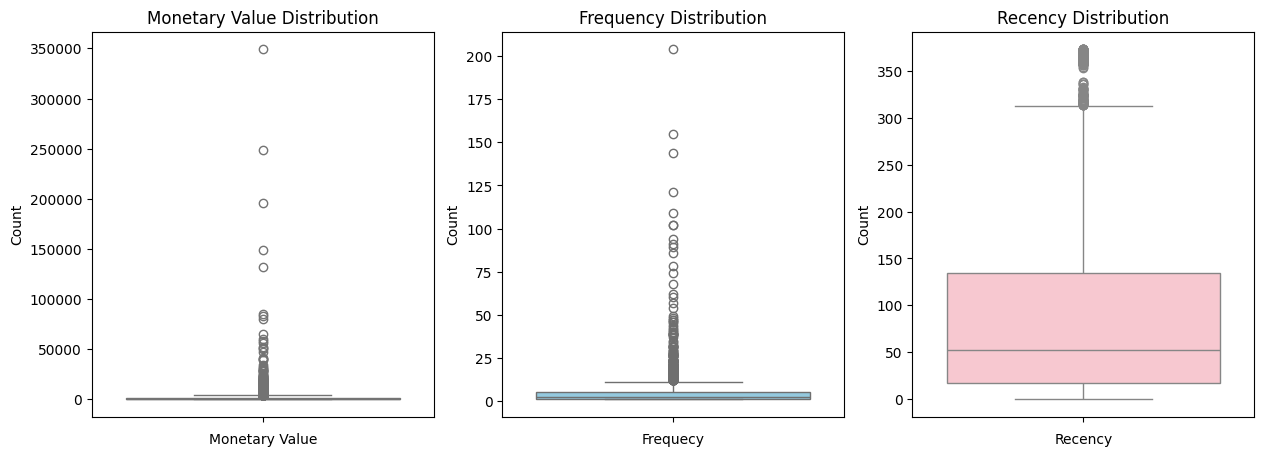

In [57]:

plt.figure(figsize = (15,5))

plt.subplot(1,3,1)
sns.boxplot(aggregated_df.MonetaryValue, color = 'lightgreen')
plt.xlabel('Monetary Value')
plt.xticks(rotation = 'vertical')
plt.ylabel('Count')
plt.title('Monetary Value Distribution')

plt.subplot(1,3,2)
sns.boxplot(aggregated_df.Frequency, color = 'skyblue')
plt.xticks(rotation = 'vertical')
plt.xlabel('Frequecy')
plt.ylabel('Count')
plt.title('Frequency Distribution')

plt.subplot(1,3,3)
sns.boxplot(aggregated_df.Recency, color = 'pink')
plt.xticks(rotation = 'vertical')
plt.xlabel('Recency')
plt.ylabel('Count')
plt.title('Recency Distribution')

- As is clear from the boxplot, there are customers who spent really much and very frequently. These are **outliers** but are the most important customers and so we cannot simply remove them from our dataset.

**How can we deal with this situation?**

We can separate outliers for separate analysis and separate categorization and use remaining for clustering using **KMeans.**

In [58]:
# IQR Method to remove outliers

MQ1 = aggregated_df.MonetaryValue.quantile(.25)
MQ3 = aggregated_df.MonetaryValue.quantile(.75)
IQM = MQ3 - MQ1

print('lower quantile:', MQ1)
print('upper quantile:', MQ3)
print('inter quantile range:', IQM)

monetary_outliers = aggregated_df[(aggregated_df.MonetaryValue > (MQ3 + 1.5 * IQM)) | (aggregated_df.MonetaryValue < (MQ1 - 1.5*IQM))]

monetary_outliers.describe()


lower quantile: 306.985
upper quantile: 1714.9325000000001
inter quantile range: 1407.9475000000002


,Customer ID,MonetaryValue,Frequency,LastInvoiceDate,Recency
count,422.000000,422.000000,422.000000,422,422.000000
mean,15053.507109,12398.608687,17.388626,2010-11-09 13:42:30.284360192,29.981043
min,12357.000000,3851.010000,1.000000,2010-01-17 11:33:00,0.000000
25%,13567.000000,4623.530000,8.000000,2010-11-08 11:09:00,3.000000
50%,14914.500000,6321.175000,12.000000,2010-11-26 11:49:00,13.000000
75%,16628.500000,10474.232500,18.750000,2010-12-06 09:50:15,31.000000
max,18260.000000,349164.350000,204.000000,2010-12-09 19:32:00,326.000000
std,1730.526844,26153.727580,20.567499,NaN,49.507164


In [59]:
FQ1 = aggregated_df.Frequency.quantile(0.25)
FQ3 = aggregated_df.Frequency.quantile(0.75)
IQF = FQ3- FQ1
FQ1, FQ3, IQF

print('lower quantile:', FQ1)
print('upper quantile:', FQ3)
print('inter quantile range:', IQF)

freq_outliers = aggregated_df[(aggregated_df.Frequency > (FQ3 + 1.5 * IQF)) | (aggregated_df.Frequency < (FQ1 - 1.5*IQF))]

freq_outliers.describe()

lower quantile: 1.0
upper quantile: 5.0
inter quantile range: 4.0


,Customer ID,MonetaryValue,Frequency,LastInvoiceDate,Recency
count,285.000000,285.000000,285.000000,285,285.000000
mean,15307.796491,14322.018547,23.887719,2010-11-23 13:55:24.631578880,15.971930
min,12422.000000,1091.440000,12.000000,2010-05-12 16:51:00,0.000000
25%,13715.000000,4330.461000,13.000000,2010-11-19 15:51:00,2.000000
50%,15311.000000,6477.670000,17.000000,2010-12-02 08:52:00,7.000000
75%,16814.000000,11535.290000,23.000000,2010-12-07 10:08:00,20.000000
max,18260.000000,349164.350000,204.000000,2010-12-09 19:32:00,211.000000
std,1773.255926,31451.735972,22.789793,NaN,25.778429


In [60]:
clean_agg_df = aggregated_df[(aggregated_df.MonetaryValue < (MQ3 + 1.5 * IQM)) & (aggregated_df.MonetaryValue > (MQ1 - 1.5*IQM)) & (aggregated_df.Frequency < (FQ3 + 1.5 * IQF)) & (aggregated_df.Frequency > (FQ1 - 1.5*IQF)) ]
clean_agg_df.shape

(3811, 5)

### Outlier Treatment

Outliers in Frequency and Monetary Value were identified using the IQR method. These extreme observations were excluded from the clustering dataset because they can disproportionately influence K-Means clustering. However, they may represent important high-value customers, so they should not be considered invalid and can be analyzed separately if required.

In [61]:
clean_agg_df.describe()

,Customer ID,MonetaryValue,Frequency,LastInvoiceDate,Recency
count,3811.000000,3811.000000,3811.000000,3811,3811.000000
mean,15372.249278,878.024833,2.819995,2010-09-02 06:24:18.530569472,98.285752
min,12346.000000,1.550000,1.000000,2009-12-01 09:55:00,0.000000
25%,13910.500000,275.625000,1.000000,2010-07-06 23:49:30,22.000000
50%,15378.000000,578.140000,2.000000,2010-10-12 10:44:00,58.000000
75%,16846.500000,1252.415000,4.000000,2010-11-17 11:26:00,155.500000
max,18287.000000,3824.790000,10.000000,2010-12-09 20:01:00,373.000000
std,1693.394395,818.210676,2.161493,NaN,98.791870


Text(0.5, 1.0, 'Recency Distribution')

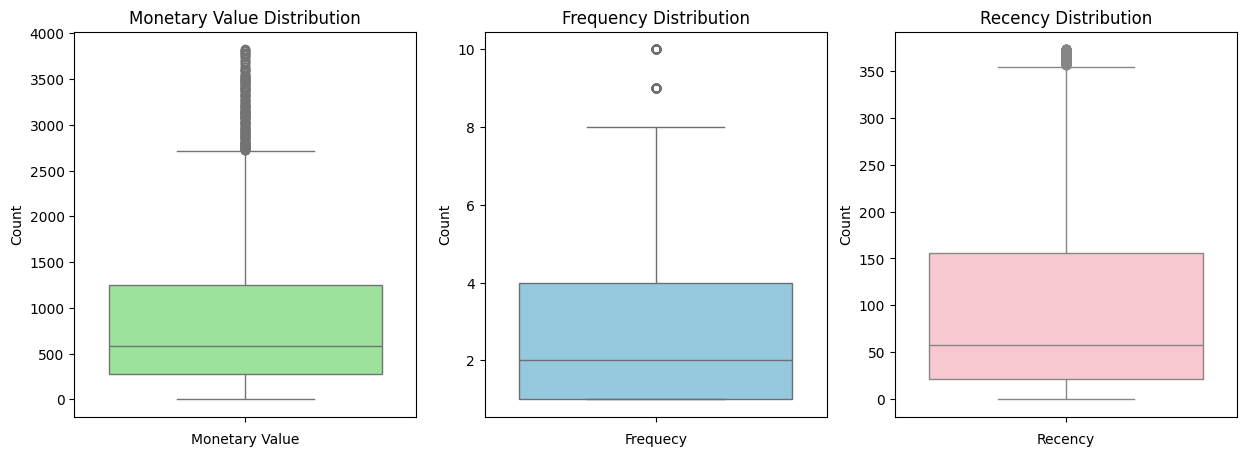

In [62]:
# boxplot for clean data
plt.figure(figsize = (15,5))

plt.subplot(1,3,1)
sns.boxplot(clean_agg_df.MonetaryValue, color = 'lightgreen')
plt.xlabel('Monetary Value')
plt.xticks(rotation = 'vertical')
plt.ylabel('Count')
plt.title('Monetary Value Distribution')

plt.subplot(1,3,2)
sns.boxplot(clean_agg_df.Frequency, color = 'skyblue')
plt.xticks(rotation = 'vertical')
plt.xlabel('Frequecy')
plt.ylabel('Count')
plt.title('Frequency Distribution')

plt.subplot(1,3,3)
sns.boxplot(clean_agg_df.Recency, color = 'pink')
plt.xticks(rotation = 'vertical')
plt.xlabel('Recency')
plt.ylabel('Count')
plt.title('Recency Distribution')

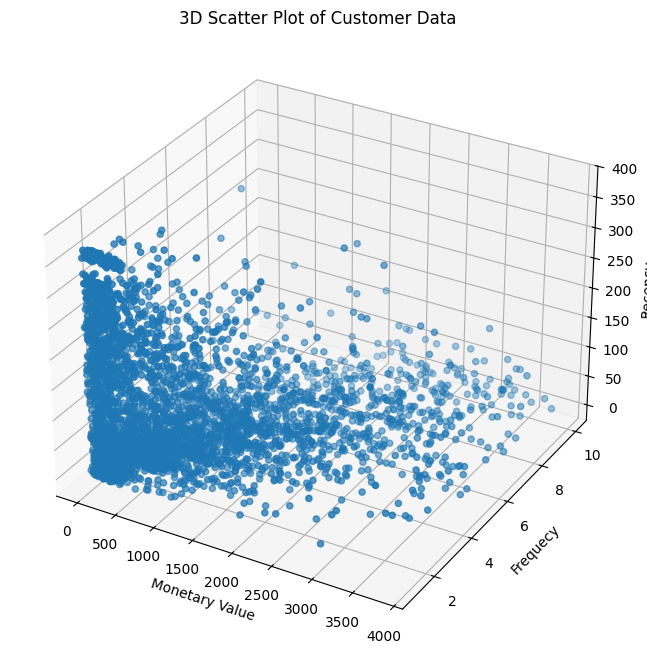

In [63]:
# 3D visualization of data across recency, frequecy and monetary values

fig = plt.figure(figsize = (10,8))

ax = fig.add_subplot(projection = '3d')

scatter = ax.scatter(clean_agg_df.MonetaryValue, clean_agg_df.Frequency, clean_agg_df.Recency)

ax.set_xlabel('Monetary Value')
ax.set_ylabel('Frequecy')
ax.set_zlabel('Recency')

ax.set_title('3D Scatter Plot of Customer Data')
plt.show()

In [64]:
# now we need to do scaling for as Kmeans algo is senstitive to scale it uses distance as measure
from sklearn.preprocessing import StandardScaler

sca = StandardScaler()
scaled_data = sca.fit_transform(clean_agg_df[['MonetaryValue','Frequency', 'Recency']])
scaled_data = pd.DataFrame(scaled_data, index = clean_agg_df.index, columns = ['MonetaryValue', 'Frequency', 'Recency'])
scaled_data

,MonetaryValue,Frequency,Recency
0,-0.866229,-0.379415,0.665266
1,0.544302,-0.379415,-0.974760
2,-0.801689,-0.842119,-0.255983
3,2.191795,0.083289,-0.569815
4,-0.705406,-0.842119,-0.893771
...,...,...,...
4307,-0.316164,1.471401,-0.822906
4308,-0.570032,-0.842119,-0.326849
4309,-0.612422,-0.842119,1.991460
4310,0.450316,-0.379415,0.128714


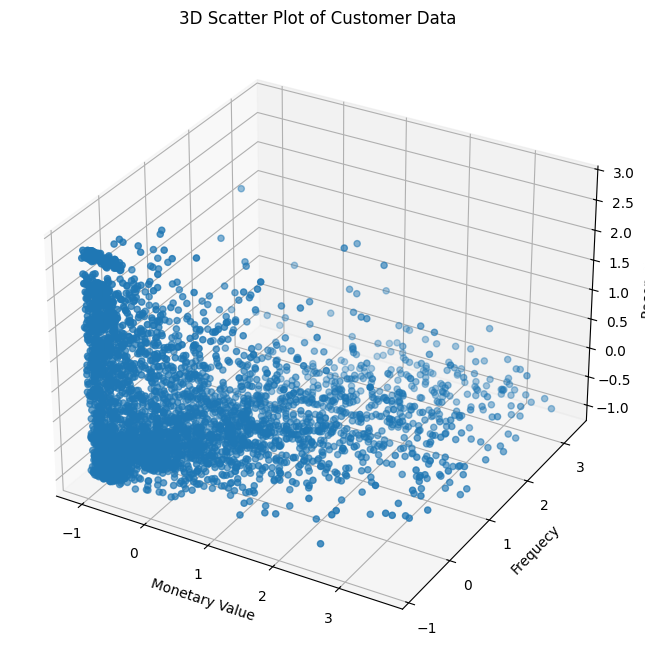

In [65]:
# checking shape retains and data scaled

fig = plt.figure(figsize = (10,8))

ax = fig.add_subplot(projection = '3d')

scatter = ax.scatter(scaled_data.MonetaryValue, scaled_data.Frequency, scaled_data.Recency)

ax.set_xlabel('Monetary Value')
ax.set_ylabel('Frequecy')
ax.set_zlabel('Recency')

ax.set_title('3D Scatter Plot of Customer Data')
plt.show()

## **Applying Kmeans CLustering Algorithm**

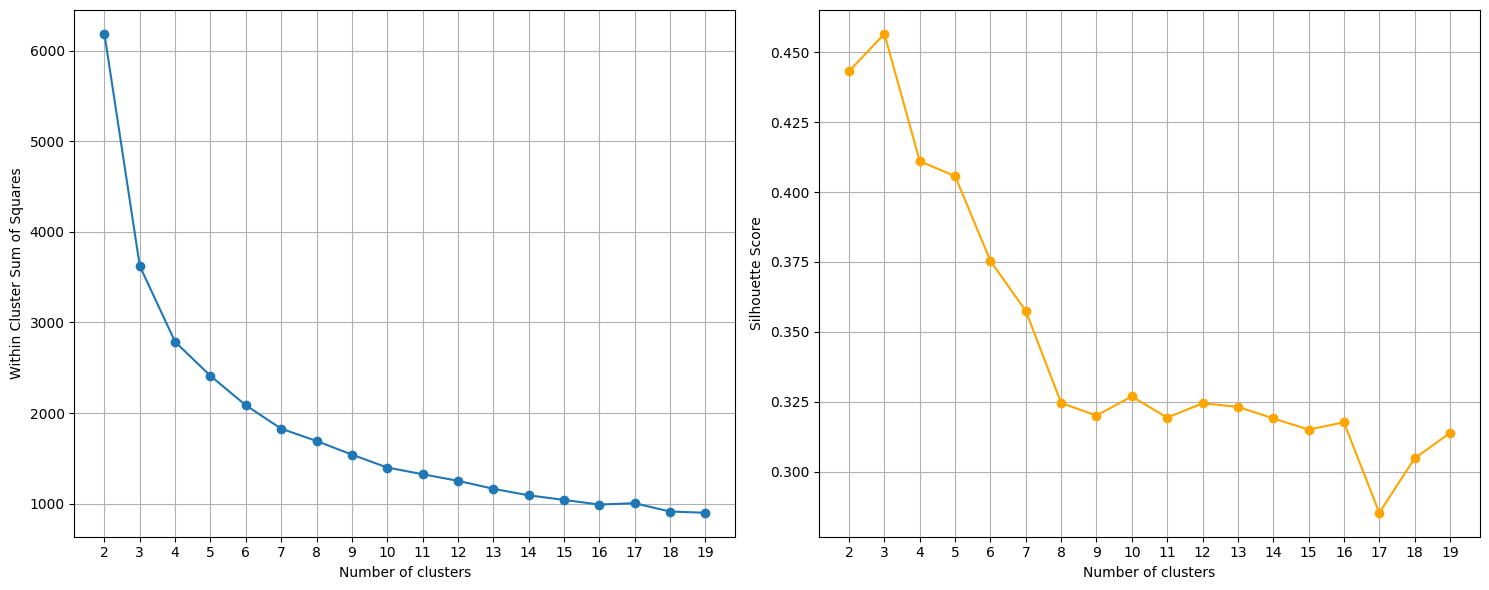

In [66]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

wcss = []
scores = []
for k in range(2,20):
  model = KMeans(n_clusters = k, init = 'k-means++')
  model.fit_predict(scaled_data)
  wcss.append(model.inertia_)
  score = silhouette_score(scaled_data, model.labels_)
  scores.append(score)
  # print(f'Silhouette score for {k} clusters: {score}')

plt.figure(figsize = (15,6))

plt.subplot(1,2,1)
plt.plot(range(2,20),wcss, marker = 'o')
plt.xticks(range(2,20))
plt.xlabel('Number of clusters')
plt.ylabel('Within Cluster Sum of Squares')
plt.grid(True)

plt.subplot(1,2,2)
plt.plot(range(2,20),scores, marker = 'o', color = 'orange')
plt.xticks(range(2,20))
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette Score')
plt.grid(True)

plt.tight_layout()
plt.show()

**Silhouette Score :**
Maximum score is for 3 clusters.
Unclear so we will use gap statistic.





## **Gap Statistic**

In [70]:
def compute_gap_statistic(X, k_max, n_replicates):
    """
    Compute the Gap Statistic for a range of cluster numbers.

    Parameters:
    X: array-like, shape (n_samples, n_features)
        The input data.
    k_max: int
        The maximum number of clusters to evaluate.
    n_replicates: int
        The number of bootstrap samples.

    Returns:
    gap_values: list
        The calculated gap values for each k.
    """
    # Generate reference data from a uniform distribution
    def generate_reference_data(X):
        return np.random.uniform(low=X.min(axis=0), high=X.max(axis=0), size=X.shape)

    gap_values = []

    # Loop over a range of k values (1 to k_max)
    for k in range(2, k_max + 1):
        # Fit KMeans to the original data
        from sklearn.cluster import KMeans
        kmeans = KMeans(n_clusters=k)
        kmeans.fit(X)
        original_inertia = kmeans.inertia_

        # Compute the average inertia for the reference datasets
        reference_inertia = []
        for _ in range(n_replicates):
            random_data = generate_reference_data(X)
            kmeans.fit(random_data)
            reference_inertia.append(kmeans.inertia_)

        # Calculate the Gap statistic
        gap = np.log(np.mean(reference_inertia)) - np.log(original_inertia)
        gap_values.append(gap)

    return gap_values

In [71]:
k_max = 13
gap_values = compute_gap_statistic(scaled_data, k_max, 10)
gap_values

[np.float64(0.6655421171228557),
 np.float64(0.9523055869681496),
 np.float64(1.0168427257461197),
 np.float64(0.9884101826390852),
 np.float64(0.9693122816452311),
 np.float64(0.974016984156246),
 np.float64(0.9534564406500916),
 np.float64(0.8966041432241934),
 np.float64(0.9192476059796117),
 np.float64(0.9717353963628366),
 np.float64(0.9761766647228605),
 np.float64(0.9696401663972054)]

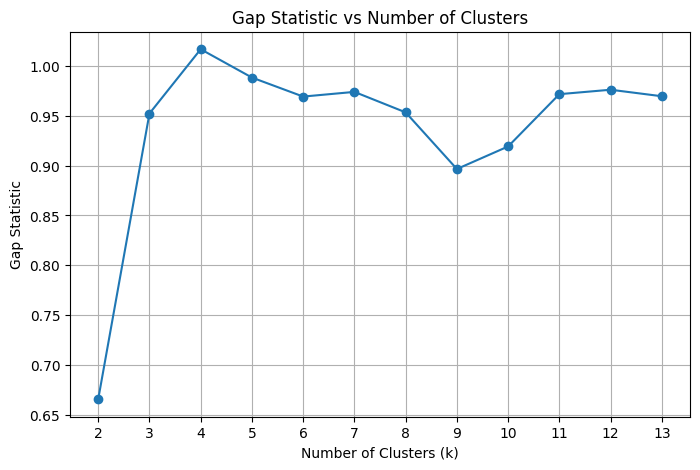

In [72]:
# Plotting the Gap Statistic
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(range(2, k_max+1), gap_values, marker='o')
plt.title('Gap Statistic vs Number of Clusters')
plt.xticks(range(2,k_max+1))
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Gap Statistic')
plt.grid()
plt.show()

### Selecting the Number of Clusters

The Elbow Method and Silhouette Score were used to evaluate different numbers of clusters. Additionally, the Gap Statistic was calculated to compare the clustering structure with a reference distribution.

The Gap Statistic reaches its maximum value at **k = 4**, supporting the selection of four clusters for the final customer segmentation.

Therefore, **k = 4** was selected for the final K-Means model.

In [73]:
kmeans = KMeans(
    n_clusters=4,
    init='k-means++',
    random_state=42
)

cluster_labels = kmeans.fit_predict(scaled_data)

clean_agg_df['labels'] = cluster_labels

C:\Users\Shubham\AppData\Local\Temp\ipykernel_13208\3269382395.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  clean_agg_df['labels'] = cluster_labels


In [74]:
cluster_size = (
    clean_agg_df['labels']
    .value_counts()
    .sort_index()
    .rename_axis('Cluster')
    .reset_index(name='Customers')
)

cluster_size['Percentage'] = (
    cluster_size['Customers'] /
    cluster_size['Customers'].sum() * 100
)

cluster_size

,Cluster,Customers,Percentage
0,0,918,24.088166
1,1,497,13.041197
2,2,1482,38.887431
3,3,914,23.983207


### Cluster Size Analysis

The size of each cluster was examined to understand how customers are distributed across the four segments. The percentage of customers in each cluster helps assess the relative importance of each customer segment.

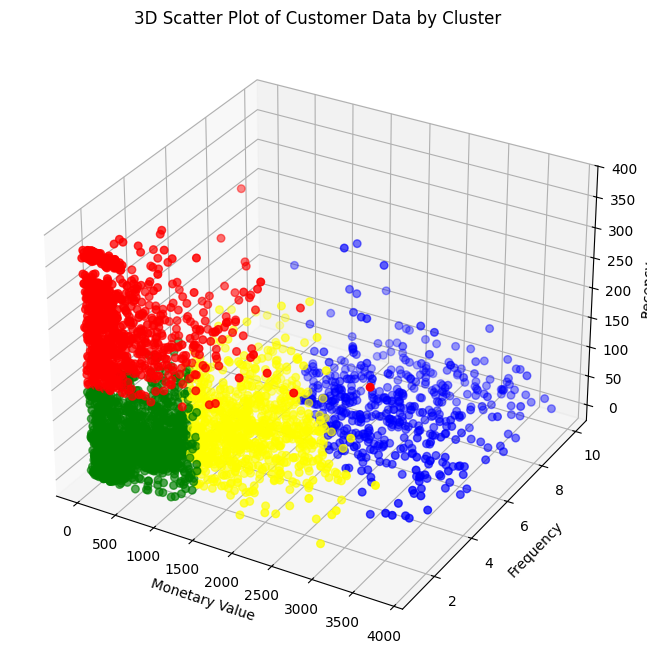

In [75]:
# visulaize data using labels
label_colors = {
    0: 'red',
    1: 'blue',
    2: 'green',
    3: 'yellow'
}

# Map labels to colors
colors = clean_agg_df['labels'].map(label_colors)

# Plot
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(clean_agg_df['MonetaryValue'], clean_agg_df['Frequency'], clean_agg_df['Recency'], c=colors, s = 30, marker = 'o')

ax.set_xlabel('Monetary Value')
ax.set_ylabel('Frequency')
ax.set_zlabel('Recency')
plt.title('3D Scatter Plot of Customer Data by Cluster')
plt.show()

In [82]:
cluster_summary = clean_agg_df.groupby('labels')[
    ['Recency', 'Frequency', 'MonetaryValue']
].mean()

cluster_summary

,Recency,Frequency,MonetaryValue
labels,,,
0,251.961874,1.428105,387.598512
1,36.488934,6.995976,2422.411153
2,54.001350,1.630229,413.294765
3,49.344639,3.876368,1284.350131


### Cluster Summary

| Cluster | Recency | Frequency | Monetary Value | Interpretation |
|---|---:|---:|---:|---|
| **0** | 251.96 | 1.43 | 387.60 | Inactive / At-Risk Customers |
| **1** | 36.49 | 7.00 | 2422.41 | VIP / High-Value Customers |
| **2** | 54.00 | 1.63 | 413.29 | Recent / Occasional Customers |
| **3** | 49.34 | 3.88 | 1284.35 | Valuable / Active Customers |

### Understanding the Cluster Values

- **Cluster 0:** Customers have an average **Recency of 251.96 days**, meaning they have not purchased for a long time. Their average **Frequency is only 1.43 purchases** and their average **Monetary Value is 387.60**, indicating low engagement and low spending. These customers can be considered **inactive or at-risk customers** and can be targeted through win-back and re-engagement campaigns.

- **Cluster 1:** Customers have the lowest average **Recency of 36.49 days**, meaning they have purchased recently. They have the highest **Frequency of 7.00 purchases** and the highest **Monetary Value of 2422.41**. These are the **VIP / high-value customers** and should be prioritized for retention, loyalty programs, and personalized offers.

- **Cluster 2:** Customers have an average **Recency of 54.00 days**, showing relatively recent activity. However, their average **Frequency is only 1.63 purchases** and their average **Monetary Value is 413.29**. These are **recent or occasional customers** who can be encouraged to purchase more frequently and increase their spending.

- **Cluster 3:** Customers have an average **Recency of 49.34 days**, indicating recent activity. Their average **Frequency is 3.88 purchases** and their average **Monetary Value is 1284.35**, which is considerably higher than Clusters 0 and 2. These customers can be considered **valuable and active customers** and can be targeted through cross-selling, upselling, and loyalty strategies.

Text(0, 0.5, 'Recency')

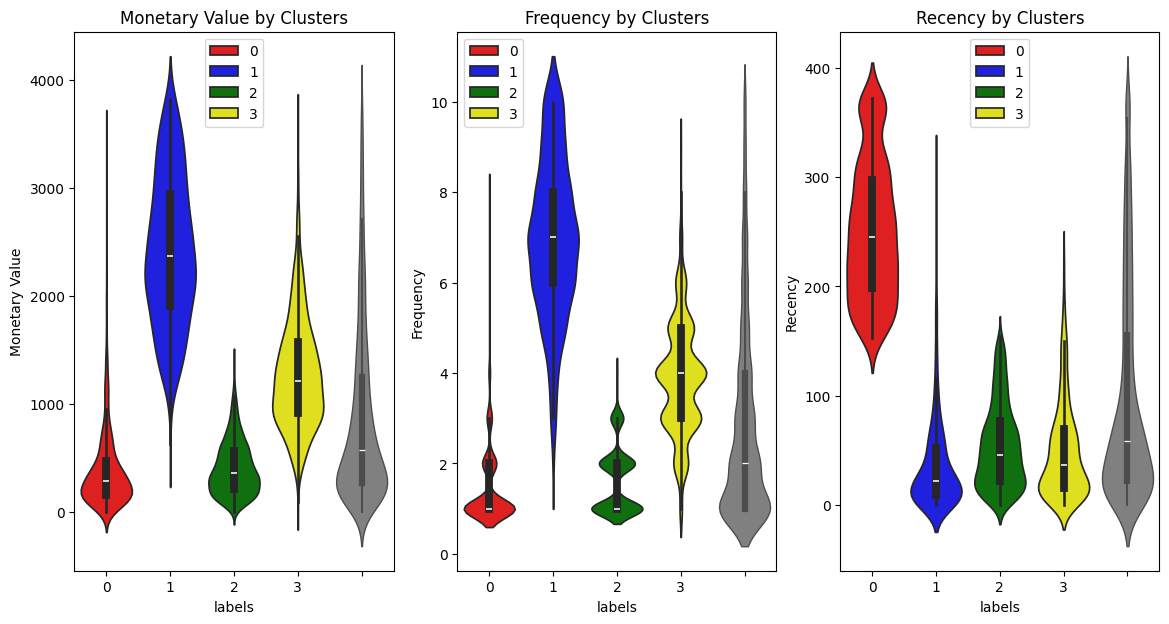

In [77]:
# Violin plot by Clusters

plt.figure(figsize= (14,7))

plt.subplot(1,3,1)
sns.violinplot(x = clean_agg_df.labels, y = clean_agg_df.MonetaryValue, palette = label_colors, hue = clean_agg_df.labels)
sns.violinplot(y = clean_agg_df.MonetaryValue, color ='gray', linewidth = 1.0)
plt.title('Monetary Value by Clusters')
plt.ylabel('Monetary Value')

plt.subplot(1,3,2)
sns.violinplot(x = clean_agg_df.labels, y = clean_agg_df.Frequency, palette = label_colors, hue = clean_agg_df.labels)
sns.violinplot(y = clean_agg_df.Frequency, color ='gray', linewidth = 1.0)
plt.title('Frequency by Clusters')
plt.ylabel('Frequency')

plt.subplot(1,3,3)
sns.violinplot(x = clean_agg_df.labels, y = clean_agg_df.Recency, palette = label_colors, hue = clean_agg_df.labels)
sns.violinplot(y = clean_agg_df.Recency, color ='gray', linewidth = 1.0)
plt.title('Recency by Clusters')
plt.ylabel('Recency')

## Interpretation

### 1) Cluster 0 - Red

**Monetary Value** - Low  
**Frequency** - Low  
**Recency** - High (less recent)

These are **inactive or at-risk customers**. They have spent relatively little, purchased infrequently, and have not purchased recently. They can be targeted with **re-engagement and win-back campaigns**.

---

### 2) Cluster 1 - Blue

**Monetary Value** - Very High  
**Frequency** - Very High  
**Recency** - Low (recent)

These are **VIP / high-value customers**. They spend the most, purchase frequently, and have been recently active. They are the **most valuable customer segment** and should be prioritized for **retention, loyalty rewards, and personalized offers**.

---

### 3) Cluster 2 - Green

**Monetary Value** - Low  
**Frequency** - Low  
**Recency** - Low to Moderate (relatively recent)

These are **recent but low-value / occasional customers**. They have made purchases recently but have relatively low spending and purchase frequency. The goal should be to **increase repeat purchases and encourage higher spending**.

---

### 4) Cluster 3 - Yellow

**Monetary Value** - High  
**Frequency** - Medium to High  
**Recency** - Low (recent)

These are **valuable and active customers**. They show relatively high spending and purchase frequency and have been recently active. They can be targeted with **cross-selling, upselling, and loyalty programs**.

In [78]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)

pca_data = pca.fit_transform(scaled_data)

pca_df = pd.DataFrame(
    pca_data,
    columns=['PC1', 'PC2']
)

pca_df['labels'] = clean_agg_df['labels'].values

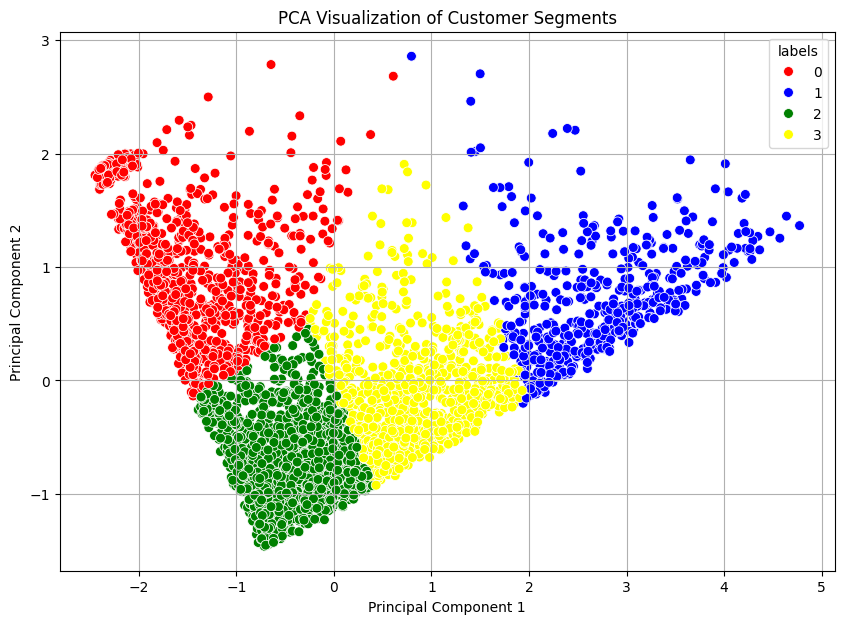

In [79]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=pca_df,
    x='PC1',
    y='PC2',
    hue='labels',
    palette=label_colors,
    s=50
)

plt.title('PCA Visualization of Customer Segments')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)
plt.show()

### PCA Visualization

Principal Component Analysis (PCA) was used to reduce the three-dimensional RFM feature space into two principal components for visualization.

The PCA plot shows that the four customer clusters occupy different regions of the reduced feature space. Although some overlap exists between the clusters, the overall separation provides a visual representation of the distinct customer segments identified by K-Means.

PCA is used here for **visualization only** and was not used to perform the clustering.

## Revenue Contribution by Cluster

To understand the business importance of each customer segment, we examine the number of customers and their contribution to total revenue.

While the RFM cluster summary describes the average purchasing behavior of each segment, revenue contribution helps us identify which segments generate the largest share of overall revenue.

In [80]:
cluster_profile = clean_agg_df.groupby('labels').agg(
    Customers=('Customer ID', 'count'),
    Avg_Recency=('Recency', 'mean'),
    Avg_Frequency=('Frequency', 'mean'),
    Avg_MonetaryValue=('MonetaryValue', 'mean'),
    Total_Revenue=('MonetaryValue', 'sum')
).reset_index()

cluster_profile['Customer_Percentage'] = (
    cluster_profile['Customers'] /
    cluster_profile['Customers'].sum() * 100
)

cluster_profile['Revenue_Percentage'] = (
    cluster_profile['Total_Revenue'] /
    cluster_profile['Total_Revenue'].sum() * 100
)

cluster_profile.round(2)

,labels,Customers,Avg_Recency,Avg_Frequency,Avg_MonetaryValue,Total_Revenue,Customer_Percentage,Revenue_Percentage
0,0,918,251.96,1.43,387.60,355815.43,24.09,10.63
1,1,497,36.49,7.00,2422.41,1203938.34,13.04,35.98
2,2,1482,54.00,1.63,413.29,612502.84,38.89,18.30
3,3,914,49.34,3.88,1284.35,1173896.02,23.98,35.08


### Revenue Contribution Insights

The revenue contribution analysis provides an important business perspective on the customer segments.

- **Cluster 1 – VIP / High-Value Customers** contains **13.04% of customers** but contributes **35.98% of total revenue**. With an average Monetary Value of **2422.41**, an average Frequency of **7.00**, and a low Recency of **36.49 days**, this is the most valuable customer segment. These customers should be given the highest priority for retention and loyalty programs.

- **Cluster 3 – Valuable / Active Customers** represents **23.98% of customers** and contributes **35.08% of total revenue**. With an average Monetary Value of **1284.35** and Frequency of **3.88**, this segment also makes a major contribution to revenue. Cross-selling, upselling, and loyalty strategies can help increase their value further.

- **Cluster 2 – Recent / Occasional Customers** is the largest segment, containing **38.89% of customers**, but contributes only **18.30% of total revenue**. These customers are relatively recent but have low purchase frequency and spending. Increasing repeat purchases can help move them toward higher-value segments.

- **Cluster 0 – Inactive / At-Risk Customers** contains **24.09% of customers** but contributes only **10.63% of total revenue**. These customers have a high average Recency of **251.96 days**, indicating that they have been inactive for a long period. Win-back and re-engagement campaigns can be used to bring them back.

### Key Business Insight

The most important finding is that **Cluster 1 and Cluster 3 together represent only 37.02% of customers but generate 71.06% of total revenue**. Therefore, retaining and strengthening relationships with these high-value customers should be a major business priority.

At the same time, the large number of customers in **Cluster 2** provides an opportunity to increase revenue by encouraging repeat purchases and moving these customers toward higher-value segments.

## Business Recommendations

Based on the RFM characteristics and revenue contribution of each customer segment, the following strategies can be adopted:

| Customer Segment | Key Characteristics | Recommended Strategy |
|---|---|---|
| **Cluster 0 – Inactive / At-Risk** | High recency, low frequency, low monetary value | Win-back campaigns, personalized discounts, and re-engagement offers |
| **Cluster 1 – VIP / High-Value** | Very recent, very frequent, highest monetary value | Loyalty rewards, exclusive offers, personalized services, and strong retention strategies |
| **Cluster 2 – Recent / Occasional** | Recent purchases but low frequency and spending | Encourage repeat purchases, product recommendations, and targeted promotions |
| **Cluster 3 – Valuable / Active** | Recent, moderately frequent, high monetary value | Cross-selling, upselling, loyalty programs, and personalized promotions |

### Strategic Priority

**Cluster 1 and Cluster 3 should receive the highest priority** because together they represent only **37.02% of customers but contribute 71.06% of total revenue**.

Cluster 2 represents the largest customer segment (**38.89%**) and provides an opportunity for growth by increasing purchase frequency and customer spending.

Cluster 0 should be targeted with cost-effective re-engagement campaigns to determine whether inactive customers can be brought back.

# Conclusion

The final K-Means clustering model divided customers into **4 distinct segments** based on their **Recency, Frequency, and Monetary Value (RFM)**.

The analysis started with data cleaning and preprocessing of the retail transaction data. Customer-level **RFM features** were created to summarize purchasing behavior. Outliers in Frequency and Monetary Value were identified using the **IQR method** and excluded from the clustering dataset to reduce their influence on the clustering process.

The RFM features were then scaled, and different numbers of clusters were evaluated using the **Elbow Method, Silhouette Score, and Gap Statistic**. Based on the overall analysis, **4 clusters were selected** for the final K-Means model.

The resulting clusters represent customers with clearly different purchasing behaviors, ranging from **inactive and occasional customers to valuable and VIP customers**. PCA was also used to visualize the customer segments in a lower-dimensional space.

These segments can help the business develop **targeted marketing strategies** instead of treating every customer in the same way. In particular, VIP customers can be retained through loyalty programs, valuable customers can be encouraged through cross-selling and upselling, occasional customers can be encouraged to make repeat purchases, and inactive customers can be targeted through win-back campaigns.

Overall, the project demonstrates how **RFM analysis and K-Means clustering can be used to transform transaction data into meaningful customer segments and actionable business insights.**